In [14]:
# ============================================================
# OpenMC Burnup and Fuel Depletion in Nuclear Systems
# ============================================================

import openmc
import openmc.deplete
import numpy as np
import matplotlib.pyplot as plt

import os

os.environ["OPENMC_CROSS_SECTIONS"] = \
"/home/clesio/openmcData/cross_sections.xml"

# ============================================================
# PARAMETERS
# ============================================================

fuel_radius = 0.40      # cm
pitch = 1.26            # cm

power_density = 30.0    # W/gHM

# Burnup schedule
days = [0.5, 1, 2, 4, 8, 16, 32]
# days = [1.0]

# ============================================================
# MATERIALS
# ============================================================

fuel = openmc.Material(name='UO2 Fuel')

fuel.add_nuclide('U235', 0.045)
fuel.add_nuclide('U238', 0.955)

fuel.add_element('O', 2.0)

fuel.set_density('g/cm3', 10.4)

# Fuel pin height used in depletion model
fuel_height = 1.0  # cm

fuel_volume = (
    np.pi *
    fuel_radius**2 *
    fuel_height
)

fuel.depletable = True
fuel.volume = fuel_volume

fuel_mass = fuel_volume * fuel.density

water = openmc.Material(name='Water')

water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)

water.set_density(
    'g/cm3',
    0.74
)

materials = openmc.Materials(
    [fuel, water]
)

materials.export_to_xml()


In [15]:
# ============================================================
# GEOMETRY
# ============================================================

fuel_cyl = openmc.ZCylinder(
    r=fuel_radius
)

xmin = openmc.XPlane(
    -pitch/2,
    boundary_type='reflective'
)

xmax = openmc.XPlane(
    pitch/2,
    boundary_type='reflective'
)

ymin = openmc.YPlane(
    -pitch/2,
    boundary_type='reflective'
)

ymax = openmc.YPlane(
    pitch/2,
    boundary_type='reflective'
)

fuel_region = -fuel_cyl

moderator_region = (
    +fuel_cyl &
    +xmin & -xmax &
    +ymin & -ymax
)

fuel_cell = openmc.Cell(
    fill=fuel,
    region=fuel_region
)

moderator_cell = openmc.Cell(
    fill=water,
    region=moderator_region
)

root = openmc.Universe(
    cells=[fuel_cell, moderator_cell]
)

geometry = openmc.Geometry(root)

geometry.export_to_xml()

In [16]:
# ============================================================
# SETTINGS
# ============================================================

settings = openmc.Settings()

settings.particles = 500
settings.batches = 20
settings.inactive = 5

bounds = [
    -pitch/2,
    -pitch/2,
    -1,
     pitch/2,
     pitch/2,
     1
]

settings.source = openmc.IndependentSource(
    space=openmc.stats.Box(
        bounds[:3],
        bounds[3:]
    )
)

settings.export_to_xml()

# ============================================================
# TALLIES
# ============================================================

tallies = openmc.Tallies()

tallies.export_to_xml()

# ============================================================
# MODEL
# ============================================================

model = openmc.Model(
    geometry,
    materials,
    settings,
    tallies
)

# operator = openmc.deplete.CoupledOperator(model)



In [17]:
# ============================================================
# DEPLETION CHAIN
# ============================================================

# Update path for your system
openmc.config["chain_file"] = (
    "/home/clesio/miniconda3/envs/openmc-env/"
    "lib/python3.11/site-packages/"
    "openmc_data/depletion/"
    "chain_endf_b8.0_pwr.xml"
)


In [18]:
# ============================================================
# OPERATOR
# ============================================================

operator = openmc.deplete.CoupledOperator(model)

# ============================================================
# FUEL MASS
# ============================================================

fuel_volume = np.pi * fuel_radius**2 * 1.0

fuel_mass = (
    fuel_volume *
    fuel.density
)

power = (
    power_density *
    fuel_mass
)

print(f"Fuel mass = {fuel_mass:.2f} g")
print(f"Power     = {power:.2f} W")


Fuel mass = 5.23 g
Power     = 156.83 W


In [19]:
print("Fuel volume =", fuel.volume)
print("Fuel mass =", fuel_mass)
print("Power =", power)

Fuel volume = 0.5026548245743669
Fuel mass = 5.227610175573417
Power = 156.8283052672025


In [20]:
sp = model.run()

print(sp)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [21]:
# ============================================================
# TIMESTEPS
# ============================================================

timesteps = [
    (d, 'd')
    for d in days
]

# ============================================================
# INTEGRATOR
# ============================================================

integrator = openmc.deplete.CECMIntegrator(
    operator,
    timesteps,
    power=power
)

print("Starting depletion calculation...")

integrator.integrate()

print("Depletion completed.")


Starting depletion calculation...
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
    

          favor of the model.xml file.


 Reading cross sections XML file...
 Reading U235 from /home/clesio/openmcData/ENDFB-8.0-NNDC_U235.h5
 Reading U238 from /home/clesio/openmcData/ENDFB-8.0-NNDC_U238.h5
 Reading O16 from /home/clesio/openmcData/ENDFB-8.0-NNDC_O16.h5
 Reading O17 from /home/clesio/openmcData/ENDFB-8.0-NNDC_O17.h5
 Reading O18 from /home/clesio/openmcData/ENDFB-8.0-NNDC_O18.h5
 Reading H1 from /home/clesio/openmcData/ENDFB-8.0-NNDC_H1.h5
 Minimum neutron data temperature: 0 K
 Maximum neutron data temperature: 1.7976931348623157e+308 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
[openmc.deplete] t=0.0 s, dt=43200.0 s, source=156.8283052672025
 Reading H2 from /home/clesio/openmcData/ENDFB-8.0-NNDC_H2.h5
 Reading He3 from /home/clesio/openmcData/ENDFB-8.0-NNDC_He3.h5
 Reading He4 from /home/clesio/openmcData/ENDFB-8.0-NNDC_He4.h5
 Reading Li6 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Li6.h5
 Reading Li7 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Li7.h5
 Reading Be9 from /home/cl

 Reading K39 from /home/clesio/openmcData/ENDFB-8.0-NNDC_K39.h5
 Reading K40 from /home/clesio/openmcData/ENDFB-8.0-NNDC_K40.h5
 Reading K41 from /home/clesio/openmcData/ENDFB-8.0-NNDC_K41.h5
 Reading Ca40 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ca40.h5
 Reading Ca42 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ca42.h5
 Reading Ca43 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ca43.h5
 Reading Ca44 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ca44.h5
 Reading Ca46 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ca46.h5
 Reading Ca48 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ca48.h5
 Reading Sc45 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sc45.h5
 Reading Ti46 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ti46.h5
 Reading Ti47 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ti47.h5
 Reading Ti48 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ti48.h5
 Reading Ti49 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ti49.h5
 Reading Ti50 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ti50.h5
 Reading V50 fro

 Reading Mo92 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo92.h5
 Reading Mo94 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo94.h5
 Reading Mo95 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo95.h5
 Reading Mo96 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo96.h5
 Reading Mo97 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo97.h5
 Reading Mo98 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo98.h5
 Reading Mo100 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Mo100.h5
 Reading Ru96 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru96.h5
 Reading Ru98 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru98.h5
 Reading Ru99 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru99.h5
 Reading Ru100 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru100.h5
 Reading Ru101 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru101.h5
 Reading Ru102 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru102.h5
 Reading Ru104 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ru104.h5
 Reading Rh103 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Rh103.h

...

 Reading Cd111 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Cd111.h5
 Reading Cd112 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Cd112.h5
 Reading Cd113 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Cd113.h5
 Reading Cd114 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Cd114.h5
 Reading Cd116 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Cd116.h5
 Reading In113 from /home/clesio/openmcData/ENDFB-8.0-NNDC_In113.h5
 Reading In115 from /home/clesio/openmcData/ENDFB-8.0-NNDC_In115.h5
 Reading Sn112 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn112.h5
 Reading Sn114 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn114.h5
 Reading Sn115 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn115.h5
 Reading Sn116 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn116.h5
 Reading Sn117 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn117.h5
 Reading Sn118 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn118.h5
 Reading Sn119 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Sn119.h5
 Reading Sn120 from /home/clesio/openmcData/ENDF

          1200K
          2500K


 Reading Te123 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Te123.h5
 Reading Te124 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Te124.h5
 Reading Te125 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Te125.h5
 Reading Te126 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Te126.h5
 Reading Te128 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Te128.h5
 Reading Te130 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Te130.h5
 Reading I127 from /home/clesio/openmcData/ENDFB-8.0-NNDC_I127.h5
 Reading Xe124 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe124.h5
 Reading Xe126 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe126.h5
 Reading Xe128 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe128.h5
 Reading Xe129 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe129.h5
 Reading Xe130 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe130.h5
 Reading Xe131 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe131.h5
 Reading Xe132 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Xe132.h5
 Reading Xe134 from /home/clesio/openmcData/ENDFB-

          1200K
          2500K
          1200K
          2500K
          1200K
          2500K
          1200K
          2500K
          1200K
          2500K
          1200K
          2500K
          1200K
          2500K


 Reading Yb173 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Yb173.h5
 Reading Yb174 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Yb174.h5
 Reading Yb176 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Yb176.h5
 Reading Lu175 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Lu175.h5
 Reading Lu176 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Lu176.h5
 Reading Hf174 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Hf174.h5
 Reading Hf176 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Hf176.h5
 Reading Hf177 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Hf177.h5
 Reading Hf178 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Hf178.h5
 Reading Hf179 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Hf179.h5
 Reading Hf180 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Hf180.h5
 Reading Ta180 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ta180.h5
 Reading Ta181 from /home/clesio/openmcData/ENDFB-8.0-NNDC_Ta181.h5
 Reading W180 from /home/clesio/openmcData/ENDFB-8.0-NNDC_W180.h5
 Reading W182 from /home/clesio/openmcData/ENDFB-8

In [22]:
# ============================================================
# RESULTS
# ============================================================

results = openmc.deplete.Results("depletion_results.h5")

# ------------------------------------------------------------
# Time history
# ------------------------------------------------------------

times = np.asarray(
    results.get_times(time_units='d')
)

# ------------------------------------------------------------
# keff history
# ------------------------------------------------------------

times_keff, keff_data = results.get_keff()

keff = keff_data[:, 0]
keff_std = keff_data[:, 1]

# ------------------------------------------------------------
# Find burnable material automatically
# ------------------------------------------------------------

mat_id = list(results[0].index_mat.keys())[0]

print("Burnable material ID =", mat_id)

# ------------------------------------------------------------
# Isotopic inventories
# ------------------------------------------------------------

t_u235, u235 = results.get_atoms(
    mat_id,
    "U235"
)

t_u238, u238 = results.get_atoms(
    mat_id,
    "U238"
)

try:
    t_pu239, pu239 = results.get_atoms(
        mat_id,
        "Pu239"
    )
except:
    pu239 = np.zeros_like(u235)

# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

print()
print("Number of depletion steps =", len(times))
print("Number of U235 points      =", len(u235))
print("Number of U238 points      =", len(u238))
print("Number of Pu239 points     =", len(pu239))

print()
print("Initial U235 =", u235[0])
print("Final U235   =", u235[-1])

print()
print("Initial keff =", keff[0])
print("Final keff   =", keff[-1])

Burnable material ID = 3

Number of depletion steps = 8
Number of U235 points      = 8
Number of U238 points      = 8
Number of Pu239 points     = 8

Initial U235 = 5.248570789091261e+20
Final U235   = 4.92602854665558e+20

Initial keff = 1.4818120147134648
Final keff   = 1.452028215372721


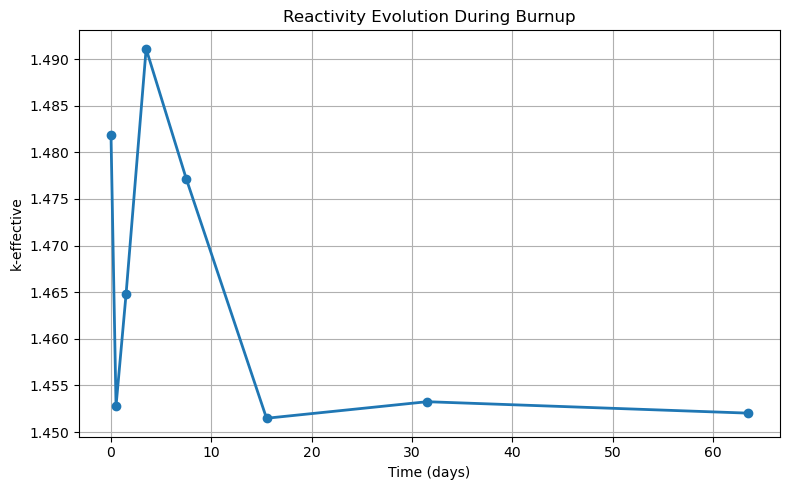

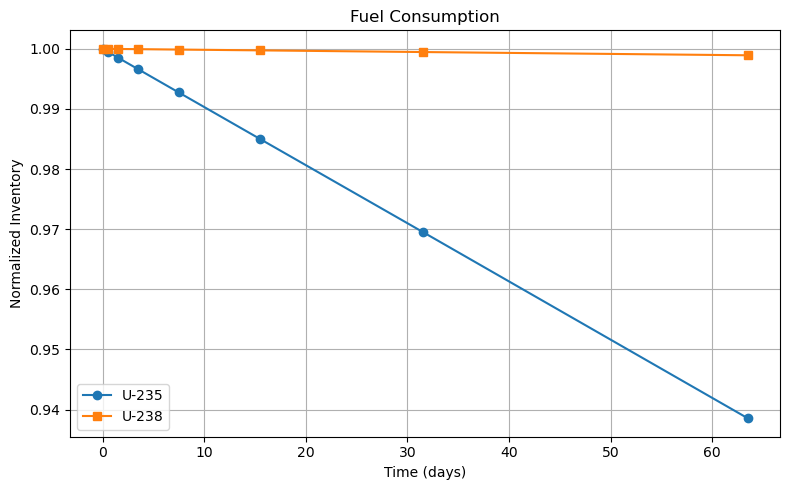

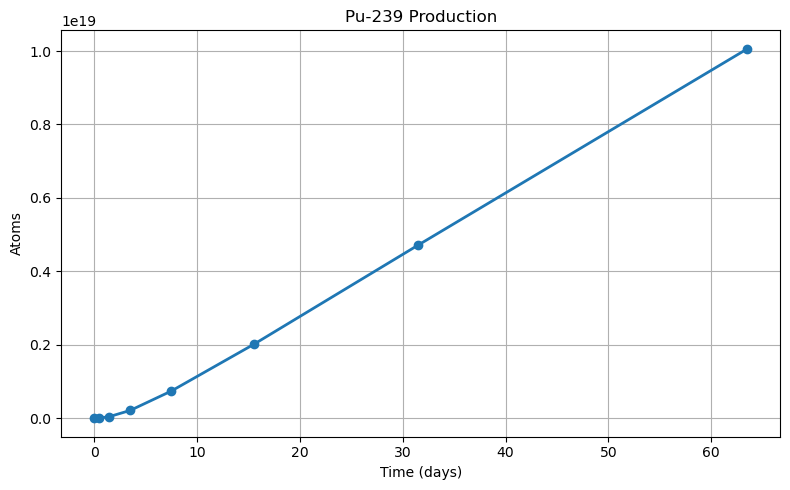


FINAL DEPLETION REPORT

Initial U235 atoms : 5.2486e+20
Final U235 atoms   : 4.9260e+20
Final Pu239 atoms  : 1.0060e+19
Initial keff       : 1.48181
Final keff         : 1.45203
U235 consumed      : 6.15%

Simulation completed successfully.


In [23]:
# ============================================================
# PLOT 1
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    times,
    keff,
    'o-',
    linewidth=2
)

plt.xlabel('Time (days)')
plt.ylabel('k-effective')

plt.title(
    'Reactivity Evolution During Burnup'
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# PLOT 2
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    times,
    u235/u235[0],
    'o-',
    label='U-235'
)

plt.plot(
    times,
    u238/u238[0],
    's-',
    label='U-238'
)

plt.xlabel('Time (days)')
plt.ylabel('Normalized Inventory')

plt.title(
    'Fuel Consumption'
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# PLOT 3
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    times,
    pu239,
    'o-',
    linewidth=2
)

plt.xlabel('Time (days)')
plt.ylabel('Atoms')

plt.title(
    'Pu-239 Production'
)

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================================
# FINAL REPORT
# ============================================================

print()
print("================================")
print("FINAL DEPLETION REPORT")
print("================================")
print()

print(
    f"Initial U235 atoms : {u235[0]:.4e}"
)

print(
    f"Final U235 atoms   : {u235[-1]:.4e}"
)

print(
    f"Final Pu239 atoms  : {pu239[-1]:.4e}"
)

print(
    f"Initial keff       : {keff[0]:.5f}"
)

print(
    f"Final keff         : {keff[-1]:.5f}"
)

burn_fraction = (
    1.0 -
    u235[-1]/u235[0]
)

print(
    f"U235 consumed      : {100*burn_fraction:.2f}%"
)

print()
print("Simulation completed successfully.")